# Introducción al Machine Learning

El **Machine Learning** (aprendizaje automático) es una rama de la Inteligencia Artificial que permite que las máquinas **aprendan patrones a partir de los datos**, sin necesidad de ser programadas explícitamente para cada tarea. En lugar de seguir reglas fijas, un modelo aprende de ejemplos y luego **generaliza** para hacer predicciones o tomar decisiones sobre datos nuevos.

## ¿Para qué sirve?

- **Clasificación**: predecir una categoría o clase (por ejemplo, si un empleado abandonará o no la empresa).
- **Regresión**: predecir un valor numérico (por ejemplo, el precio de una vivienda).
- **Agrupamiento (clustering)**: descubrir grupos en los datos sin etiquetas previas.
- **Detección de anomalías**, **sistemas de recomendación**, **visión por computadora**, etc.

## Tipos de entrenamiento

| Tipo | Descripción | Ejemplos |
| --- | --- | --- |
| **Supervisado** | Aprende de datos etiquetados (se conoce la respuesta correcta). | Clasificación y regresión |
| **No supervisado** | Descubre patrones en datos sin etiquetar. | Clustering, reducción de dimensionalidad |
| **Por refuerzo** | Aprende por ensayo y error maximizando una recompensa. | Juegos, robótica |

## Flujo típico de un proyecto de Machine Learning

1. Cargar y entender los datos.
2. Explorar y limpiar los datos (EDA).
3. Preparar las variables: codificar categóricas y escalar numéricas.
4. Dividir los datos en **entrenamiento** y **prueba**.
5. Entrenar el modelo.
6. Evaluar el modelo y, si tiene buen desempeño, **publicarlo** para su uso (por ejemplo, en una Web API).


## Ejercicio práctico: Predecir si un emplado abanonará su trabajo

En este ejercicio utilizaremos el modelo de clasificación k-NN que clasifica observaciones basándose en los k vecinos más cercanos.

Es necesario instalar libreria Sklearn:
```python
python -m pip install scikit-learn
```

In [ ]:
!python -m pip install scikit-learn

## Paso 1: Cargar y preparar datos

En este paso **cargamos el dataset** con `pandas` y lo **preparamos**:

- `pd.read_csv(...)`: lee el archivo CSV (usa `sep=";"` porque el archivo separa las columnas con punto y coma).
- `data.columns` y `data.dtypes`: muestran el nombre y el tipo de cada columna.
- `isna().sum()`: cuenta los valores nulos por columna.
- `drop(...)`: elimina columnas que no aportan al análisis (por ejemplo, `anos_en_puesto` y `conciliacion`, que tienen muchos nulos).

In [127]:
import pandas as pd

# Cargar los datos
data = pd.read_csv("./data/abandono_empleados.csv", sep=";")
# Mostrando las columnas
print(data.columns)
print(data.dtypes)
print(data.shape)
data.head()

Index(['edad', 'abandono', 'viajes', 'departamento', 'distancia_casa',
       'educacion', 'carrera', 'empleados', 'id', 'satisfaccion_entorno',
       'sexo', 'implicacion', 'nivel_laboral', 'puesto',
       'satisfaccion_trabajo', 'estado_civil', 'salario_mes',
       'num_empresas_anteriores', 'mayor_edad', 'horas_extra',
       'incremento_salario_porc', 'evaluacion', 'satisfaccion_companeros',
       'horas_quincena', 'nivel_acciones', 'anos_experiencia',
       'num_formaciones_ult_ano', 'conciliacion', 'anos_compania',
       'anos_en_puesto', 'anos_desde_ult_promocion',
       'anos_con_manager_actual'],
      dtype='str')
edad                          int64
abandono                        str
viajes                          str
departamento                    str
distancia_casa                int64
educacion                       str
carrera                         str
empleados                     int64
id                            int64
satisfaccion_entorno            str
s

,edad,abandono,viajes,departamento,distancia_casa,educacion,carrera,empleados,id,satisfaccion_entorno,...,satisfaccion_companeros,horas_quincena,nivel_acciones,anos_experiencia,num_formaciones_ult_ano,conciliacion,anos_compania,anos_en_puesto,anos_desde_ult_promocion,anos_con_manager_actual
0,41,Yes,Travel_Rarely,Sales,1,Universitaria,Life Sciences,1,1,Media,...,Baja,80,0,8,0,#N/D,6,NaN,0,5
1,49,No,Travel_Frequently,Research & Development,8,Secundaria,Life Sciences,1,2,Alta,...,Muy_Alta,80,1,10,3,#N/D,10,NaN,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,Secundaria,Other,1,4,Muy_Alta,...,Media,80,0,7,3,#N/D,0,2.0,0,0
3,33,No,Travel_Frequently,Research & Development,3,Universitaria,Life Sciences,1,5,Muy_Alta,...,Alta,80,0,8,3,#N/D,8,3.0,3,0
4,27,No,Travel_Rarely,Research & Development,2,Universitaria,Medical,1,7,Baja,...,Muy_Alta,80,1,6,3,#N/D,2,NaN,2,2


In [128]:
# Revisando datos nulos
data.isna().sum().sort_values(ascending=False)

anos_en_puesto              1238
edad                           0
viajes                         0
abandono                       0
distancia_casa                 0
educacion                      0
carrera                        0
departamento                   0
id                             0
satisfaccion_entorno           0
sexo                           0
implicacion                    0
nivel_laboral                  0
puesto                         0
satisfaccion_trabajo           0
empleados                      0
estado_civil                   0
salario_mes                    0
mayor_edad                     0
num_empresas_anteriores        0
incremento_salario_porc        0
evaluacion                     0
satisfaccion_companeros        0
horas_extra                    0
horas_quincena                 0
nivel_acciones                 0
num_formaciones_ult_ano        0
anos_experiencia               0
conciliacion                   0
anos_compania                  0
anos_desde

In [129]:
# Limpiando datos
data = data.drop(columns=["anos_en_puesto", "conciliacion"])
data.head()

,edad,abandono,viajes,departamento,distancia_casa,educacion,carrera,empleados,id,satisfaccion_entorno,...,incremento_salario_porc,evaluacion,satisfaccion_companeros,horas_quincena,nivel_acciones,anos_experiencia,num_formaciones_ult_ano,anos_compania,anos_desde_ult_promocion,anos_con_manager_actual
0,41,Yes,Travel_Rarely,Sales,1,Universitaria,Life Sciences,1,1,Media,...,11,Alta,Baja,80,0,8,0,6,0,5
1,49,No,Travel_Frequently,Research & Development,8,Secundaria,Life Sciences,1,2,Alta,...,23,Muy_Alta,Muy_Alta,80,1,10,3,10,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,Secundaria,Other,1,4,Muy_Alta,...,15,Alta,Media,80,0,7,3,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,Universitaria,Life Sciences,1,5,Muy_Alta,...,11,Alta,Alta,80,0,8,3,8,3,0
4,27,No,Travel_Rarely,Research & Development,2,Universitaria,Medical,1,7,Baja,...,12,Alta,Muy_Alta,80,1,6,3,2,2,2


In [130]:
# Eliminamos las con valores nulos
data = data.dropna()

## Paso 2: Análisis Exploratorio (EDA)

Aquí **exploramos los datos** para entenderlos antes de modelar:

- Se generan **gráficos de barras** de las variables categóricas para ver su distribución.
- Se eliminan columnas **constantes**, que no aportan información (`mayor_edad`, `empleados` y `horas_quincena`).
- Se calculan **estadísticos descriptivos** de las variables numéricas (`describe` + mediana).
- Se analiza la **variable objetivo** (`abandono`) y su relación con educación, estado civil, horas extras, puesto, viajes y salario.

In [131]:
# Explorar las los atributos relevantes
def graficos_eda_categoricos(cat):
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

C:\Users\Marlon\AppData\Local\Temp\ipykernel_5512\129580392.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  graficos_eda_categoricos(data.select_dtypes('O'))


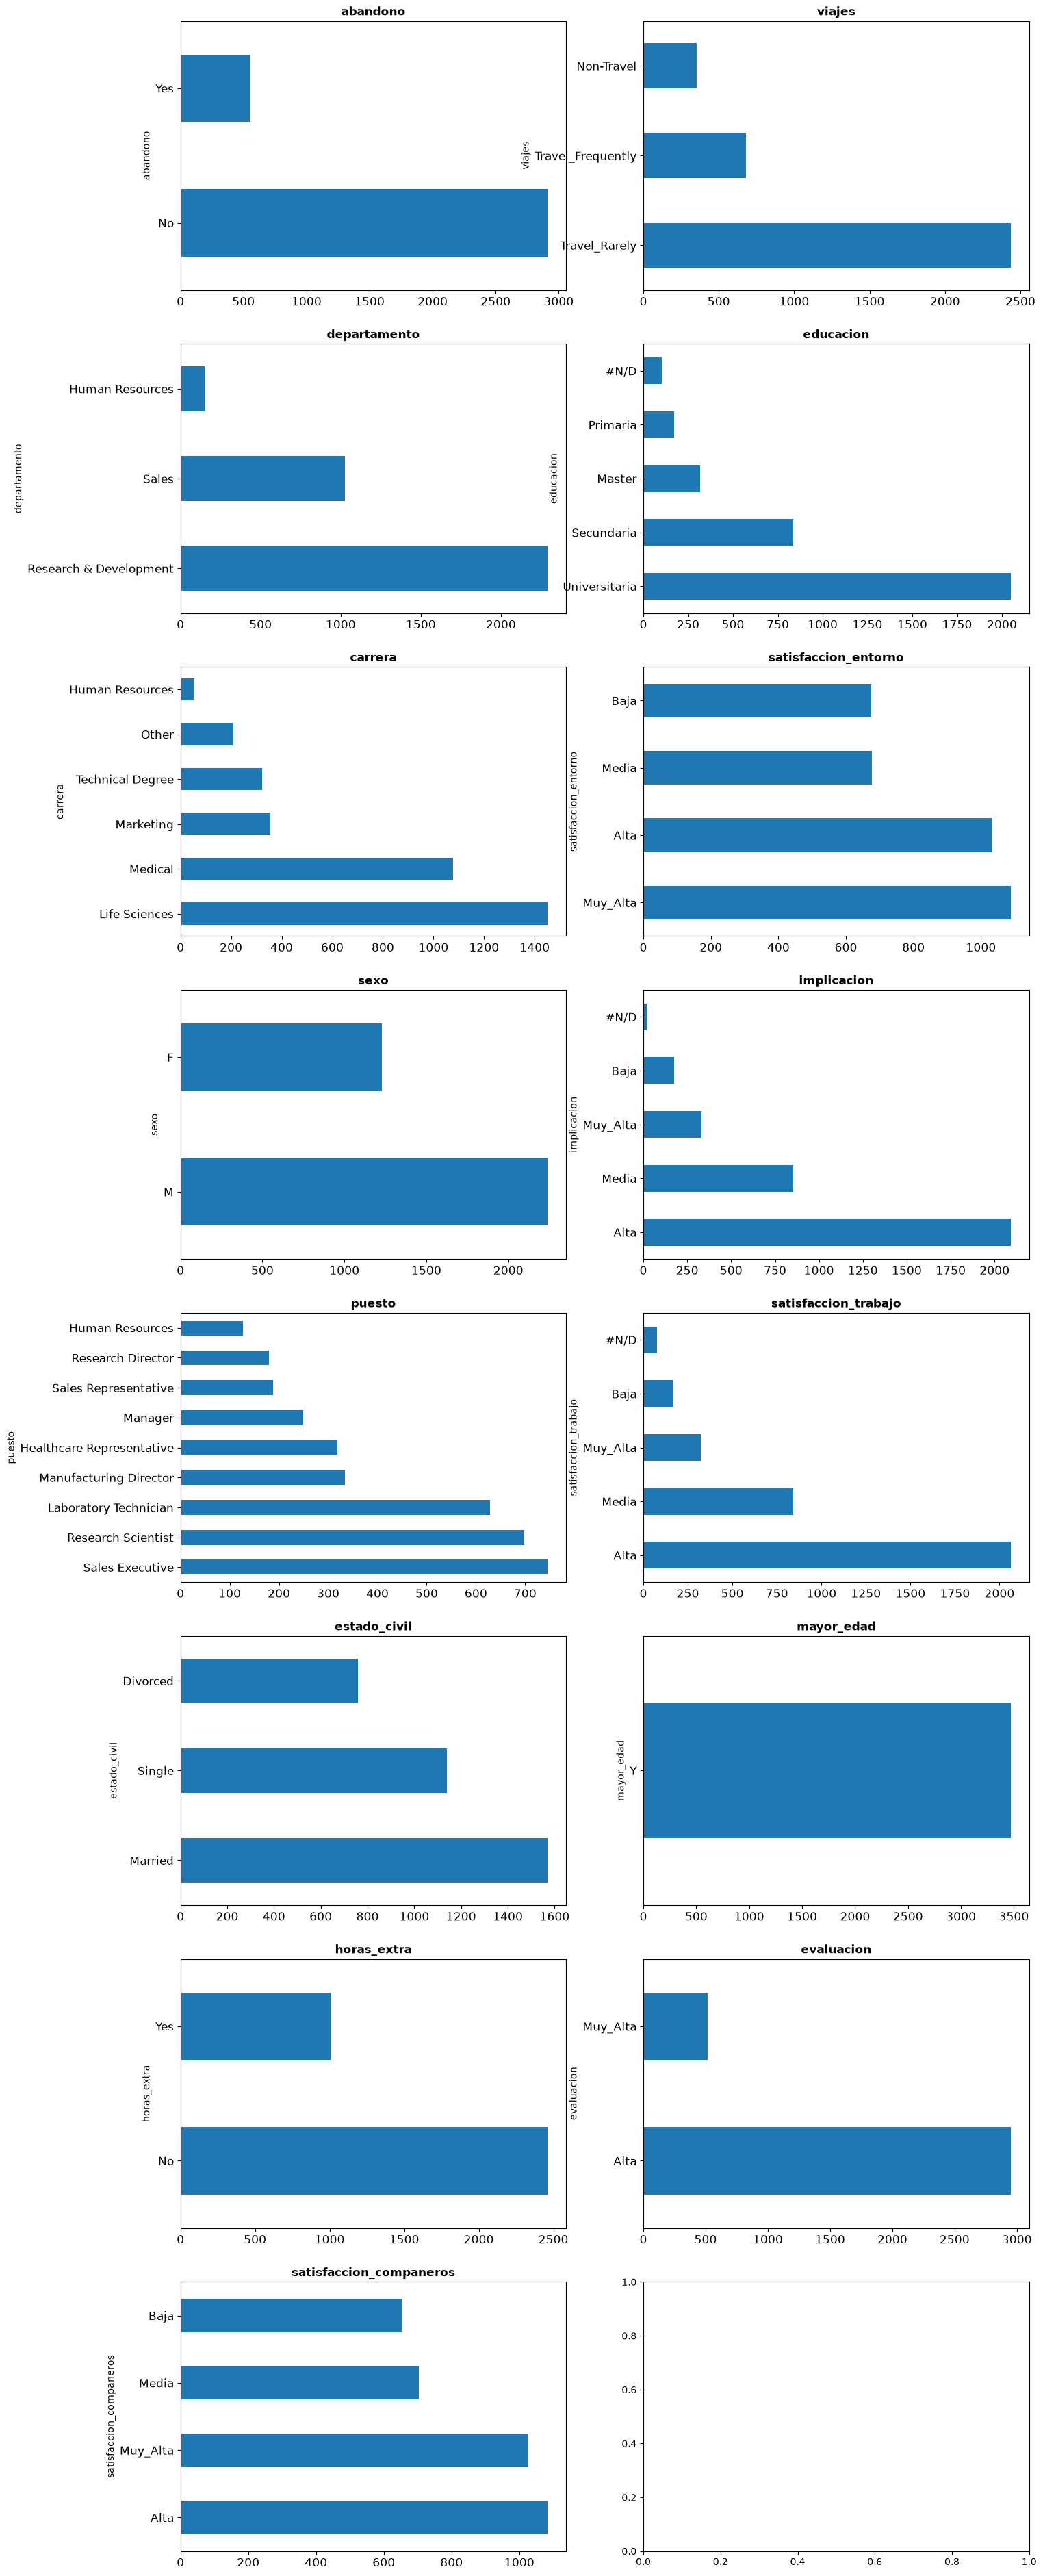

In [132]:
import matplotlib.pyplot as plt

graficos_eda_categoricos(data.select_dtypes('O'))

In [133]:
# Conclusiones de la exploración de datos
# - Eliminar columna "mayor_edad" porque es un valor consante
data = data.drop("mayor_edad", axis=1)
data.head()

,edad,abandono,viajes,departamento,distancia_casa,educacion,carrera,empleados,id,satisfaccion_entorno,...,incremento_salario_porc,evaluacion,satisfaccion_companeros,horas_quincena,nivel_acciones,anos_experiencia,num_formaciones_ult_ano,anos_compania,anos_desde_ult_promocion,anos_con_manager_actual
0,41,Yes,Travel_Rarely,Sales,1,Universitaria,Life Sciences,1,1,Media,...,11,Alta,Baja,80,0,8,0,6,0,5
1,49,No,Travel_Frequently,Research & Development,8,Secundaria,Life Sciences,1,2,Alta,...,23,Muy_Alta,Muy_Alta,80,1,10,3,10,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,Secundaria,Other,1,4,Muy_Alta,...,15,Alta,Media,80,0,7,3,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,Universitaria,Life Sciences,1,5,Muy_Alta,...,11,Alta,Alta,80,0,8,3,8,3,0
4,27,No,Travel_Rarely,Research & Development,2,Universitaria,Medical,1,7,Baja,...,12,Alta,Muy_Alta,80,1,6,3,2,2,2


In [134]:
# Eliminar los datos con el valor "#N/D" que aparecen en las columnas "educacion", "implicacion" y "satisfaccion_trabajo"
data = data[(data["educacion"] != "#N/D") & (data["implicacion"] != "#N/D") & (data["satisfaccion_trabajo"] != "#N/D")]

In [135]:
# Mostrar el tamaño del dataset después de eliminar los datos con "#ND"
print(data.shape)

(3315, 29)


In [136]:
# Buscando el valor "#ND" en el dataset
data.isin(["#N/D"]).sum().sort_values(ascending=False)

edad                        0
abandono                    0
viajes                      0
departamento                0
distancia_casa              0
educacion                   0
carrera                     0
empleados                   0
id                          0
satisfaccion_entorno        0
sexo                        0
implicacion                 0
nivel_laboral               0
puesto                      0
satisfaccion_trabajo        0
estado_civil                0
salario_mes                 0
num_empresas_anteriores     0
horas_extra                 0
incremento_salario_porc     0
evaluacion                  0
satisfaccion_companeros     0
horas_quincena              0
nivel_acciones              0
anos_experiencia            0
num_formaciones_ult_ano     0
anos_compania               0
anos_desde_ult_promocion    0
anos_con_manager_actual     0
dtype: int64

In [137]:
# Eliminamos la columna ID porque no es relevante para el modelo
data = data.drop("id", axis=1)
data.head()

,edad,abandono,viajes,departamento,distancia_casa,educacion,carrera,empleados,satisfaccion_entorno,sexo,...,incremento_salario_porc,evaluacion,satisfaccion_companeros,horas_quincena,nivel_acciones,anos_experiencia,num_formaciones_ult_ano,anos_compania,anos_desde_ult_promocion,anos_con_manager_actual
0,41,Yes,Travel_Rarely,Sales,1,Universitaria,Life Sciences,1,Media,M,...,11,Alta,Baja,80,0,8,0,6,0,5
1,49,No,Travel_Frequently,Research & Development,8,Secundaria,Life Sciences,1,Alta,F,...,23,Muy_Alta,Muy_Alta,80,1,10,3,10,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,Secundaria,Other,1,Muy_Alta,F,...,15,Alta,Media,80,0,7,3,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,Universitaria,Life Sciences,1,Muy_Alta,M,...,11,Alta,Alta,80,0,8,3,8,3,0
4,27,No,Travel_Rarely,Research & Development,2,Universitaria,Medical,1,Baja,M,...,12,Alta,Muy_Alta,80,1,6,3,2,2,2


In [138]:
# Mostrar las estadisticas de los valores númericos
def estadisticos_cont(num):
    #Calculamos describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

estadisticos_cont(data.select_dtypes('number'))

,count,mean,median,std,min,25%,50%,75%,max
edad,3315.0,36.992760,36.0,9.203097,18.0,30.0,36.0,43.0,60.0
distancia_casa,3315.0,9.152640,7.0,8.053434,1.0,2.0,7.0,14.0,29.0
empleados,3315.0,1.000000,1.0,0.000000,1.0,1.0,1.0,1.0,1.0
nivel_laboral,3315.0,2.066667,2.0,1.115841,1.0,1.0,2.0,3.0,5.0
salario_mes,3315.0,6522.476621,5019.0,4752.030510,1009.0,3018.5,5019.0,8333.5,19999.0
num_empresas_anteriores,3315.0,2.703771,2.0,2.467600,0.0,1.0,2.0,4.0,9.0
incremento_salario_porc,3315.0,15.174057,14.0,3.640224,11.0,12.0,14.0,18.0,25.0
horas_quincena,3315.0,80.000000,80.0,0.000000,80.0,80.0,80.0,80.0,80.0
nivel_acciones,3315.0,0.781297,1.0,0.851078,0.0,0.0,1.0,1.0,3.0
anos_experiencia,3315.0,11.304072,9.0,7.729539,0.0,6.0,9.0,15.0,40.0


In [139]:
# Conclusiones del análisis estadístico de los datos
# - Eliminar columnas "empleados" y "horas_quincena"  porque tienen valores consantes
data = data.drop(columns=["empleados", "horas_quincena"])
data.head()

,edad,abandono,viajes,departamento,distancia_casa,educacion,carrera,satisfaccion_entorno,sexo,implicacion,...,horas_extra,incremento_salario_porc,evaluacion,satisfaccion_companeros,nivel_acciones,anos_experiencia,num_formaciones_ult_ano,anos_compania,anos_desde_ult_promocion,anos_con_manager_actual
0,41,Yes,Travel_Rarely,Sales,1,Universitaria,Life Sciences,Media,M,Alta,...,Yes,11,Alta,Baja,0,8,0,6,0,5
1,49,No,Travel_Frequently,Research & Development,8,Secundaria,Life Sciences,Alta,F,Media,...,No,23,Muy_Alta,Muy_Alta,1,10,3,10,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,Secundaria,Other,Muy_Alta,F,Media,...,Yes,15,Alta,Media,0,7,3,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,Universitaria,Life Sciences,Muy_Alta,M,Alta,...,Yes,11,Alta,Alta,0,8,3,8,3,0
4,27,No,Travel_Rarely,Research & Development,2,Universitaria,Medical,Baja,M,Alta,...,No,12,Alta,Muy_Alta,1,6,3,2,2,2


In [140]:
# Ver el comportamiento de la variable dependiente (abando)
data.abandono.value_counts(normalize = True) * 100

abandono
No     84.042232
Yes    15.957768
Name: proportion, dtype: float64

<Axes: xlabel='educacion'>

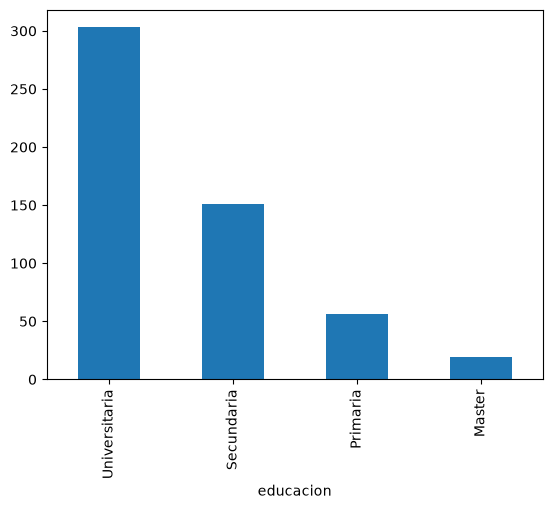

In [141]:
# Análisis por Educación
df_edu = data[data["abandono"]=='Yes'].groupby("educacion").abandono.count().sort_values(ascending=False)
df_edu.plot.bar()

<Axes: xlabel='estado_civil'>

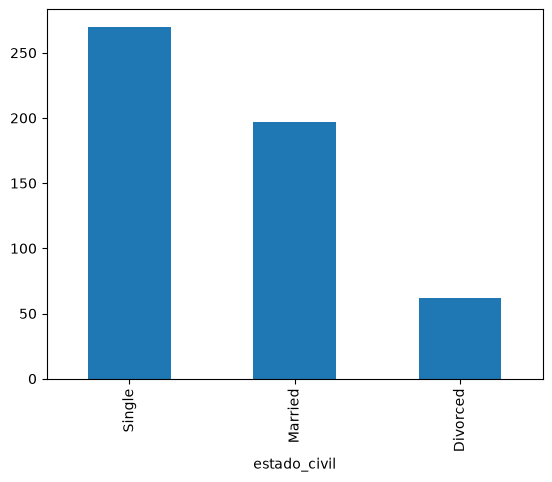

In [142]:
# Análisis por estado civil
df_ec = data[data["abandono"]=='Yes'].groupby("estado_civil").abandono.count().sort_values(ascending=False)
df_ec.plot.bar()

<Axes: xlabel='horas_extra'>

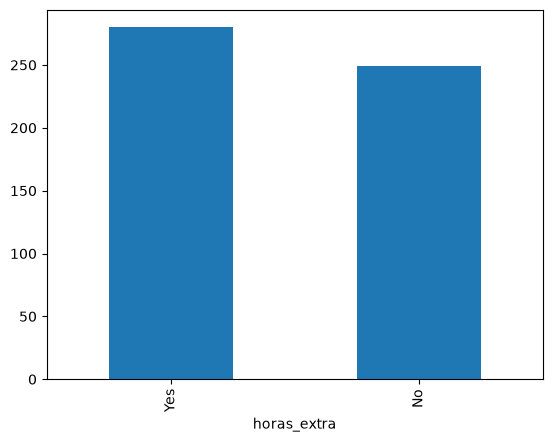

In [143]:
# Analisis por horas extras
df_hr = data[data["abandono"]=='Yes'].groupby("horas_extra").abandono.count().sort_values(ascending=False)
df_hr.plot.bar()

<Axes: xlabel='puesto'>

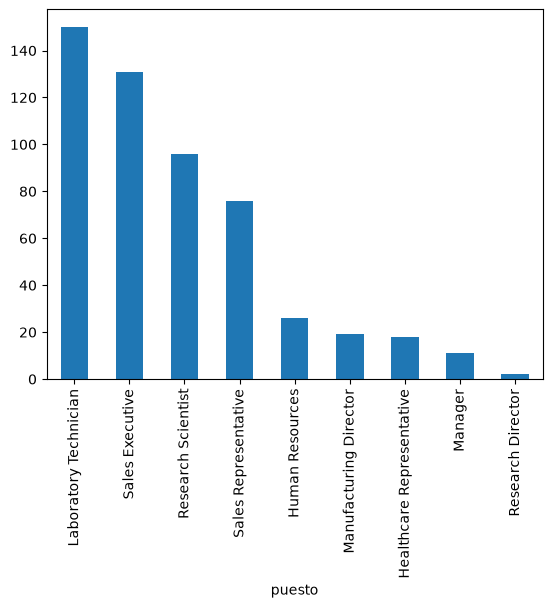

In [144]:
# Analisis por puesto
df_p = data[data["abandono"]=='Yes'].groupby("puesto").abandono.count().sort_values(ascending=False)
df_p.plot.bar()

<Axes: xlabel='viajes'>

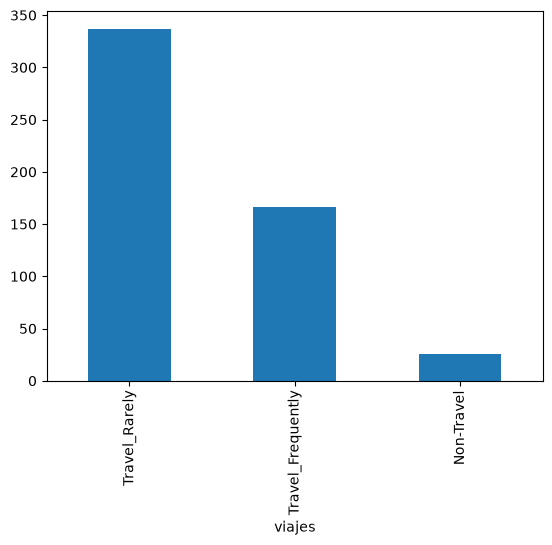

In [145]:
# Analisis por viaje
df_v = data[data["abandono"]=='Yes'].groupby("viajes").abandono.count().sort_values(ascending=False)
df_v.plot.bar()

<Axes: xlabel='abandono'>

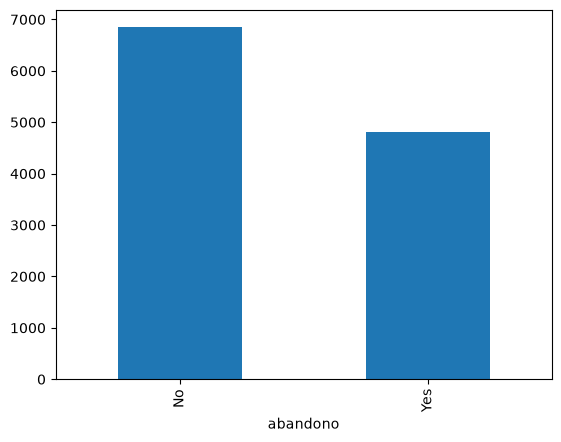

In [146]:
# Análisis de salario promedio por abandono
df_s = data.groupby('abandono').salario_mes.mean()
df_s.plot.bar()

In [147]:
# Mostrando las columnas de dataset limpio
data.dtypes

edad                        int64
abandono                      str
viajes                        str
departamento                  str
distancia_casa              int64
educacion                     str
carrera                       str
satisfaccion_entorno          str
sexo                          str
implicacion                   str
nivel_laboral               int64
puesto                        str
satisfaccion_trabajo          str
estado_civil                  str
salario_mes                 int64
num_empresas_anteriores     int64
horas_extra                   str
incremento_salario_porc     int64
evaluacion                    str
satisfaccion_companeros       str
nivel_acciones              int64
anos_experiencia            int64
num_formaciones_ult_ano     int64
anos_compania               int64
anos_desde_ult_promocion    int64
anos_con_manager_actual     int64
dtype: object

## Paso 3: Codificar y Segmentar datos

En este paso **preparamos los datos para el modelo**, que solo trabaja con números:

- `LabelEncoder`: convierte las **categorías en números** (por ejemplo, `Yes`/`No` → `1`/`0`).
- Se define `X` (variables de entrada, sin la columna `abandono`) y `y` (la variable a predecir: `abandono`).
- `train_test_split`: separa los datos en **entrenamiento** (80 %) y **prueba** (20 %).
- `StandardScaler`: **escala** las variables para que todas tengan la misma magnitud; es importante para k-NN, que mide distancias.

In [148]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Clasificación de variable cualitativas (categorias)
categorical_columns = ["abandono", "viajes", "departamento", "educacion", "carrera", "satisfaccion_entorno", 
                       "sexo", "implicacion", "puesto", "satisfaccion_trabajo", "estado_civil", "horas_extra", "evaluacion", 
                       "satisfaccion_companeros"]
labels_econders = {}
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    labels_econders[col] = le

labels_econders

{'abandono': LabelEncoder(),
 'viajes': LabelEncoder(),
 'departamento': LabelEncoder(),
 'educacion': LabelEncoder(),
 'carrera': LabelEncoder(),
 'satisfaccion_entorno': LabelEncoder(),
 'sexo': LabelEncoder(),
 'implicacion': LabelEncoder(),
 'puesto': LabelEncoder(),
 'satisfaccion_trabajo': LabelEncoder(),
 'estado_civil': LabelEncoder(),
 'horas_extra': LabelEncoder(),
 'evaluacion': LabelEncoder(),
 'satisfaccion_companeros': LabelEncoder()}

In [149]:
from sklearn.model_selection import train_test_split

# Definir variable independiente
X = data.drop("abandono", axis=1)
# Definir variable dependiente
y = data["abandono"]

# Divir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalando las caracteristicas
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


In [150]:
# Mostrando el tamaño de los datasets de entrenamiento y prueba
print("Tamaño del dataset de entrenamiento:", X_train.shape)
print("Tamaño del dataset de prueba:", X_test.shape)

Tamaño del dataset de entrenamiento: (2652, 25)
Tamaño del dataset de prueba: (663, 25)


## Paso 4: Entrenar el modelo

Aquí **entrenamos el modelo**:

- `KNeighborsClassifier(n_neighbors=5)`: crea el clasificador k-NN que decidirá según los **5 vecinos más cercanos**.
- `knn.fit(X_train, y_train)`: el modelo **aprende** los patrones del conjunto de entrenamiento.

In [151]:
# Entrenamiento del modelo
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## Paso 5: Evaluar el modelo

En este paso **evaluamos el modelo** con datos que no ha visto durante el entrenamiento:

- `knn.predict(X_test)`: genera las **predicciones** sobre el conjunto de prueba.
- `classification_report`: compara las predicciones con las etiquetas reales y muestra **precisión, recall y f1-score**.
- Después, en la siguiente celda, haremos una **predicción con un dato real**.

In [152]:
# Evaluando el modelo
# Predicciones
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       566
           1       0.64      0.44      0.52        97

    accuracy                           0.88       663
   macro avg       0.78      0.70      0.73       663
weighted avg       0.87      0.88      0.87       663



In [153]:
# Predicción con un dato real: un nuevo empleado
# Preparamos un empleado de ejemplo con las mismas columnas que usó el modelo
empleado_nuevo = pd.DataFrame([{
    'edad': 34,
    'viajes': 'Travel_Rarely',
    'departamento': 'Sales',
    'distancia_casa': 4,
    'educacion': 'Universitaria',
    'carrera': 'Marketing',
    'satisfaccion_entorno': 'Alta',
    'sexo': 'M',
    'implicacion': 'Alta',
    'nivel_laboral': 2,
    'puesto': 'Sales Executive',
    'satisfaccion_trabajo': 'Baja',
    'estado_civil': 'Single',
    'salario_mes': 2600,
    'num_empresas_anteriores': 3,
    'horas_extra': 'Yes',
    'incremento_salario_porc': 12,
    'evaluacion': 'Alta',
    'satisfaccion_companeros': 'Alta',
    'nivel_acciones': 1,
    'anos_experiencia': 6,
    'num_formaciones_ult_ano': 2,
    'anos_compania': 2,
    'anos_desde_ult_promocion': 1,
    'anos_con_manager_actual': 1,
}])

# Aseguramos el mismo orden de columnas que usó el modelo
empleado_nuevo = empleado_nuevo[X.columns]

# Codificamos las variables categóricas con los codificadores guardados
for col in categorical_columns:
    if col != "abandono":
        empleado_nuevo[col] = labels_econders[col].transform(empleado_nuevo[col])

# Escalamos con el mismo escalador del entrenamiento
empleado_nuevo_escalado = scaler.transform(empleado_nuevo)

# Predecimos si el nuevo empleado abandonará la empresa
prediccion = knn.predict(empleado_nuevo_escalado)[0]
resultado = labels_econders["abandono"].inverse_transform([prediccion])[0]

print("Predicción de abandono para el nuevo empleado:", resultado)

Predicción de abandono para el nuevo empleado: No


## Paso 6: Publicar el modelo

Para que el modelo pueda utilizarse desde otras aplicaciones, se **serializa** (se guarda en disco) junto con todas sus transformaciones (codificadores y escalador) y luego se expone mediante una **Web API**. De esta forma, cualquier sistema puede enviar los datos de un empleado y recibir la predicción sin necesidad de volver a entrenar el modelo.

In [ ]:
import joblib

# Guardamos el modelo y todo lo necesario para predecir
artefactos = {
    "modelo": knn,
    "escalador": scaler,
    "codificadores": labels_econders,
    "columnas": list(X.columns),
}

joblib.dump(artefactos, "./exports/modelo_abandono.joblib")
print("Modelo y transformaciones guardados en './exports/modelo_abandono.joblib'")

# Verificamos que se puede volver a cargar
cargado = joblib.load("./exports/modelo_abandono.joblib")
print("Modelo cargado correctamente:", type(cargado["modelo"]).__name__)
print("Columnas esperadas por el modelo:", cargado["columnas"])

### Web API con FastAPI

Creamos una API que recibe los datos de un empleado y devuelve la predicción de abandono. Escribimos el código en un archivo para poder ejecutarlo como un servicio.

In [ ]:
%%writefile api_abandono.py
# Web API para predecir el abandono de empleados
import joblib
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

# Cargamos el modelo y sus transformaciones
artefactos = joblib.load("modelo_abandono.joblib")
modelo = artefactos["modelo"]
escalador = artefactos["escalador"]
codificadores = artefactos["codificadores"]
columnas = artefactos["columnas"]

app = FastAPI(title="API de predicción de abandono de empleados")


class Empleado(BaseModel):
    edad: int
    viajes: str
    departamento: str
    distancia_casa: int
    educacion: str
    carrera: str
    satisfaccion_entorno: str
    sexo: str
    implicacion: str
    nivel_laboral: int
    puesto: str
    satisfaccion_trabajo: str
    estado_civil: str
    salario_mes: int
    num_empresas_anteriores: int
    horas_extra: str
    incremento_salario_porc: int
    evaluacion: str
    satisfaccion_companeros: str
    nivel_acciones: int
    anos_experiencia: int
    num_formaciones_ult_ano: int
    anos_compania: int
    anos_desde_ult_promocion: int
    anos_con_manager_actual: int


@app.get("/")
def raiz():
    return {"mensaje": "API de predicción de abandono de empleados"}


@app.post("/predecir")
def predecir(empleado: Empleado):
    # Convertimos a DataFrame respetando el orden de columnas del modelo
    fila = pd.DataFrame([empleado.model_dump()])[columnas]

    # Codificamos las variables categóricas
    for col in codificadores:
        if col != "abandono":
            fila[col] = codificadores[col].transform(fila[col])

    # Escalamos y predecimos
    fila_escalada = escalador.transform(fila)
    prediccion = modelo.predict(fila_escalada)[0]
    resultado = codificadores["abandono"].inverse_transform([prediccion])[0]

    return {"prediccion_abandono": resultado}

Para ejecutar la API desde una terminal:

```bash
uvicorn api_abandono:app --reload
```

Luego se puede probar con una petición POST:

```python
import requests

empleado = {
    "edad": 34, "viajes": "Travel_Rarely", "departamento": "Sales",
    "distancia_casa": 4, "educacion": "Universitaria", "carrera": "Marketing",
    "satisfaccion_entorno": "Alta", "sexo": "F",
    "implicacion": "Alta", "nivel_laboral": 2, "puesto": "Sales Executive",
    "satisfaccion_trabajo": "Baja", "estado_civil": "Single",
    "salario_mes": 2600, "num_empresas_anteriores": 3, "horas_extra": "Yes",
    "incremento_salario_porc": 12, "evaluacion": "Alta",
    "satisfaccion_companeros": "Alta", "nivel_acciones": 1,
    "anos_experiencia": 6, "num_formaciones_ult_ano": 2,
    "anos_compania": 2, "anos_desde_ult_promocion": 1,
    "anos_con_manager_actual": 1,
}

respuesta = requests.post("http://127.0.0.1:8000/predecir", json=empleado)
print(respuesta.json())
```